In [ ]:
#Chinese RNN

In [ ]:
#Install Packages

In [1]:
!pip install pandas

In [2]:
!pip install numpy

In [3]:
!pip install scikit-learn

In [4]:
!pip install tensorflow==2.20.0

In [5]:
!pip install tensorflow_hub

In [6]:
!pip install tensorflow_text

ERROR: Could not find a version that satisfies the requirement tensorflow_text (from versions: none)
ERROR: No matching distribution found for tensorflow_text


In [7]:
!pip install tf_keras

In [8]:
#Make sure that these above libraries are imported first
#Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflow_hub as hub
#import tensorflow_text as tf_text
#from tensorflow import keras
#from tensorflow.keras import layers
#import tf_keras

/opt/anaconda3/envs/old_env/lib/python3.12/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
from sklearn.metrics import confusion_matrix

In [3]:
#Step 1: Import data
column_names = ['Sentiment', 'Text']
chinese_data = pd.read_csv("/Users/johncburns/Documents/New_Research/Blue Sky/Weibo/China_Data/test.csv", names = column_names, header = None)
chinese_data.head()

,Sentiment,Text
0,2,特地网上预约的，满方便的。去了就能拿票了。\n去的那天人满少的，还有画展。\n里面有专门的讲...
1,2,拿身份证领票，早上8点45开始放票，可是那个时候已经又很多很多人排队了，所以还是更早去吧，看...
2,2,记得当时博物馆刚开始免费的时候，每次路过都看到那排队排到烈士公园。过了一年就好多了。我们去那...
3,2,之前已经上网订好票，所以好方便就入左去啦。\n里面有好多辛追夫人一家嘅陪葬品，仲有辛追夫人嘅...
4,1,票是免费的，好像是每天有3000张免费票，拿着身份证就可以领。\n但是入馆要排队，一批一批的...


In [4]:
#Fix the sentiment
chinese_data["Edit_Sentiment"] = 0
lencd = len(chinese_data)
for i in range(0, lencd):
    chinese_data["Edit_Sentiment"][i] = chinese_data["Sentiment"][i] - 1
chinese_data.tail()

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



,Sentiment,Text,Edit_Sentiment
499995,2,没吃过大龙就不要说你吃过正宗的重庆火锅，隐隐中，江湖传说只有大龙和赵二才能代表真正的重庆火锅...,1
499996,2,确实味道非常的不错~！是我这种无辣不欢的人滴最爱！典型的重庆老火锅，天天爆满！地方不太好找，...,1
499997,2,"大龙火锅属于典型的重庆老火锅,味道鲜香,又麻又辣,很远就能闻到香味.它家的菜品非常新鲜但份量...",1
499998,2,我有个同事的家就住在大龙火锅附近，她是那里的常客了！每次去都会把她喜欢吃的菜品一一点一份，最...,1
499999,1,真的很一般。。。不晓得是不是不能用老友的原因。。\n位置特别不好找啊不好找。到了那里说下午5...,0


In [5]:
#Drop Sentiment column
cd_5 = chinese_data.drop('Sentiment', axis=1)
cd_5.tail()

,Text,Edit_Sentiment
499995,没吃过大龙就不要说你吃过正宗的重庆火锅，隐隐中，江湖传说只有大龙和赵二才能代表真正的重庆火锅...,1
499996,确实味道非常的不错~！是我这种无辣不欢的人滴最爱！典型的重庆老火锅，天天爆满！地方不太好找，...,1
499997,"大龙火锅属于典型的重庆老火锅,味道鲜香,又麻又辣,很远就能闻到香味.它家的菜品非常新鲜但份量...",1
499998,我有个同事的家就住在大龙火锅附近，她是那里的常客了！每次去都会把她喜欢吃的菜品一一点一份，最...,1
499999,真的很一般。。。不晓得是不是不能用老友的原因。。\n位置特别不好找啊不好找。到了那里说下午5...,0


In [6]:
#Shuffle data
from sklearn.utils import shuffle
cd2 = shuffle(cd_5, random_state = 12345)
cd3 = cd2.reset_index(drop = True)
cd3.tail()

,Text,Edit_Sentiment
499995,去海南是8:30分的飞机，过了安检就去这家吃了早点。包子和新亚大包的差不多，皮蛋瘦肉粥味道也...,0
499996,珍味汤馆，淡淡的名字，淡淡的装修，淡淡的菜品。虽说名之为汤馆，汤的品种也不少，却没有在各种汤...,1
499997,南京西路上我还是相对喜欢这家快餐店\n主要是环境好吧\n下沉式的结构\n采光的不错\n加上可...,1
499998,第一次吃DQ忘记是什么味道了，反正就是很甜。后来听从大众的建议换成抹茶味的，哇，很好啊，不甜...,1
499999,开在南丹路上，但不太起眼，很容易会错过。离星游程很近，吃饭比较方便。比经济连锁酒店稍微豪华点...,0


In [7]:
#Split of Sentiment Data
name_counts = cd3['Edit_Sentiment'].value_counts()
name_counts

Edit_Sentiment
0    250000
1    250000
Name: count, dtype: int64

In [20]:
#Step 2: Break data into training and testing
X_train_full, X_test = train_test_split(cd3, random_state = 99914)
#X_train, X_valid = train_test_split(X_train_full, random_state = 99915)
X_train_full.to_csv("/Users/johncburns/Documents/New_Research/Blue Sky/Weibo/China_Data/X_train_full.csv")
X_test.to_csv("/Users/johncburns/Documents/New_Research/Blue Sky/Weibo/China_Data/X_test.csv")

In [20]:
#Step 3: Clearing out any previous Keras runs as I will most like be reruning the model a few times
#keras.backend.clear_session()
#tf.keras.backend.set_floatx('float64')

In [21]:
#hub_layer = hub.KerasLayer(
#    "https://www.kaggle.com/models/google/nnlm/TensorFlow2/zh-dim128-with-normalization/1",
#    trainable=True
#)

In [22]:
#print(type(hub_layer))

In [23]:
print(tf.__version__)
print(hub.__version__)

2.20.0
0.16.1


In [124]:
#!pip uninstall tensorflow tensorflow-hub -y
#!pip install tensorflow==2.18.0 
#!pip install tensorflow-hub==0.16.1

In [105]:
#model = hub.load("https://www.kaggle.com/models/google/nnlm/TensorFlow2/tf2-preview-zh-dim128-with-normalization/1")
#model = hub.load("https://www.kaggle.com/models/google/nnlm/TensorFlow2/zh-dim128-with-normalization/1")
#print(model.signatures.keys())

In [105]:
#model = hub.load("https://www.kaggle.com/models/google/nnlm/TensorFlow2/tf2-preview-zh-dim128-with-normalization/1")
#model = hub.load("https://www.kaggle.com/models/google/nnlm/TensorFlow2/zh-dim128-with-normalization/1")
#print(model.signatures.keys())

In [106]:
#hub_layer_wrapper.trainable

In [125]:
#This worked:
#https://github.com/tensorflow/tensorflow/issues/63085
#Other links
#https://stackoverflow.com/questions/66852256/error-while-loading-wiki40b-embeddings-from-tensorflow-hub
#https://www.kaggle.com/models/google/nnlm/tensorFlow2/tf2-preview-zh-dim128-with-normalization/1?tfhub-redirect=true
#https://stackoverflow.com/questions/78530756/error-only-instances-of-keras-layer-can-be-added-to-a-sequential-model
#https://stackoverflow.com/questions/55324762/the-added-layer-must-be-an-instance-of-class-layer-found-tensorflow-python-ke
#x = "https://www.kaggle.com/models/google/nnlm/TensorFlow2/tf2-preview-zh-dim128-with-normalization/1"
#x = "https://www.kaggle.com/models/google/nnlm/TensorFlow2/zh-dim128-with-normalization/1"
#hub_layer_wrapper = tf.keras.layers.Lambda(lambda x: hub_layer(x))
#hub_layer = hub.KerasLayer(x, trainable=True)
#hub_layer_wrapper.trainable = True

#model = tf.keras.Sequential([
#    tf.keras.layers.Input(shape=(), dtype=tf.string),
#    hub_layer,

#    tf.keras.layers.Dense(128, activation='relu'),
#    tf.keras.layers.BatchNormalization(),
#    tf.keras.layers.Dropout(.1),

#    tf.keras.layers.Dense(128, activation='relu'),
#    tf.keras.layers.BatchNormalization(),
#    tf.keras.layers.Dropout(.1),

#    tf.keras.layers.Dense(64, activation='relu'),
#    tf.keras.layers.BatchNormalization(),
#    tf.keras.layers.Dropout(.05),

#    tf.keras.layers.Dense(32),
#    tf.keras.layers.BatchNormalization(),
#    tf.keras.layers.Dropout(.1),

#    tf.keras.layers.Dense(1, activation='sigmoid')
#])

#model.summary()

In [126]:
#inputs = tf.keras.Input(shape=(), dtype=tf.string)

#x = hub_layer(inputs)

#x = tf.keras.layers.Dense(128, activation='relu')(x)
#x = tf.keras.layers.BatchNormalization()(x)
#x = tf.keras.layers.Dropout(.1)(x)

#x = tf.keras.layers.Dense(128, activation='relu')(x)
#x = tf.keras.layers.BatchNormalization()(x)
#x = tf.keras.layers.Dropout(.1)(x)

#x = tf.keras.layers.Dense(64, activation='relu')(x)
#x = tf.keras.layers.BatchNormalization()(x)
#x = tf.keras.layers.Dropout(.05)(x)

#x = tf.keras.layers.Dense(32)(x)
#x = tf.keras.layers.BatchNormalization()(x)
#x = tf.keras.layers.Dropout(.1)(x)

#outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

#model = tf.keras.Model(inputs, outputs)

#model.summary()

In [127]:
#Build the model 
#In Keras, an "unbuilt" layer refers to a layer (or a model) that has not yet had its parameters (weights and biases) 
#initialized because it has not received input data with a defined shape
#Have to build the model manually
#https://stackoverflow.com/questions/78662784/why-does-the-keras-embedding-layer-result-in-an-unbuilt-model-in-the-summary
#sequence_length = 1
#model.build(input_shape=(None, 1))
#model.summary()

In [128]:
#Check if model has been built
#if not model.built:
#    print("Model is not built yet.")

In [129]:
#Setting up a focal loss function
#def focal_loss(gamma=2., alpha=0.25):
#    def loss(y_true, y_pred):
#        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
#        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
#        return -alpha * tf.pow(1. - pt, gamma) * tf.math.log(pt)
#    return loss

In [130]:
#Set Optimizer
#optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)

In [131]:
#Step 2: Compile the model
#model.compile(loss = focal_loss(), optimizer = optimizer, metrics = ["accuracy", 
#                                                                              tf.keras.metrics.AUC(name="auc"),
#                                                                              tf.keras.metrics.Precision(name="precision"), 
#                                                                              tf.keras.metrics.Recall(name="recall")])

In [132]:
#BATCH_SIZE = 16

#zh_train = tf.data.Dataset.from_tensor_slices(
#    (
#        tf.cast(X_train['Text'].values, tf.string),
#        tf.cast(X_train['Edit_Sentiment'].values, tf.float32)
#    )
#).shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#zh_valid = tf.data.Dataset.from_tensor_slices(
#    (
#        tf.cast(X_valid['Text'].values, tf.string),
#        tf.cast(X_valid['Edit_Sentiment'].values, tf.float32)
#    )
#).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#zh_test = tf.data.Dataset.from_tensor_slices(
#    (
#        tf.cast(X_test['Text'].values, tf.string),
#        tf.cast(X_test['Edit_Sentiment'].values, tf.float32)
#    )
#).batch(BATCH_SIZE)

In [134]:
#Step 3: Convert training data to tf dataframe
#zh_train = (
#    tf.data.Dataset.from_tensor_slices(
#    
#        (
#            tf.cast(X_train['Text'].values, tf.string),
#            tf.cast(X_train['Edit_Sentiment'].values, tf.int64)
#        )
#    )
#)

In [133]:
#Step 4: Convert Testing data to tf dataframe
#zh_test = (
#    tf.data.Dataset.from_tensor_slices(
#    
#        (
#            tf.cast(X_test['Text'].values, tf.string),
#            tf.cast(X_test['Edit_Sentiment'].values, tf.int64)
#        )
#    )
#)

In [135]:
#Step 5: Convert Validation data to tf dataframe
#zh_valid = (
#    tf.data.Dataset.from_tensor_slices(
##    
 #       (
#            tf.cast(X_valid['Text'].values, tf.string),
#            tf.cast(X_valid['Edit_Sentiment'].values, tf.int64)
#        )
#    )
#)

In [136]:
#print(type(X_train))
#print(X_train)

In [137]:
#Step 6: Batch the data
#batch_size = 16
#X_train_set = zh_train.batch(batch_size).prefetch(1)

In [138]:
#Step 7: Set up validation data
#X_valid_set = zh_valid.batch(batch_size).prefetch(1)

In [139]:
#Step 7.5: Add an early stopping callback
#https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping
#callback = tf.keras.callbacks.EarlyStopping(monitor = "val_loss", patience = 3)
#This call back will stop the training when val_loss has not improved in 2 epochs

In [140]:
#Step 8: Fuck it, lets see if this works
#history_zh = model.fit(X_train_set, epochs = 50,
#                       validation_data = (X_valid_set),
#                       callbacks = [callback])

In [141]:
#Step 9: Set up Testing data
#X_test_set = zh_test.batch(batch_size).prefetch(1)

In [142]:
#Step 10: Using the Model to predict data
#X_test_pred = model.predict(zh_test) 

In [143]:
#X_test_pred

In [144]:
#Step 11: Compare 
#data_test_test = X_test

In [145]:
#data_test_test["results"] = X_test_pred.tolist()
#data_test_test.tail(20)

In [146]:
#Step 12: Reset index
#datatt = data_test_test.reset_index(drop = True)
#datatt.tail()

In [147]:
#Step 13: Convert Results to 0, 1
#def convert(df, i):
#    if (df["results"][i][0]) > 0.5:
#        return 1
#    else:
#        return 0

In [148]:
#Edit the results 
#datatt["edit_results"] = 0
#for i in range(0, lendtt):
#    datatt["edit_results"][i] = convert(datatt, i)

In [304]:
#datatt.tail()

In [299]:
#Confusion Matrix Chinese
#cm_zh = confusion_matrix(datatt["Edit_Sentiment"], datatt["edit_results"])

In [149]:
#cm_zh

In [150]:
#Step 16: Breakdown of Confusion Matrix, Finding the True Positives
#Negative_Total_zh = cm_zh[0,0] + cm_zh[0,1]
#TNeg_zh = cm_zh[0,0] / Negative_Total_zh
#Positive_Total_zh = cm_zh[1,0] + cm_zh[1,1]
#TPos_zh = cm_zh[1,1] / Positive_Total_zh
#TotalAcc_zh = (cm_zh[0,0] + cm_zh[1,1]) / (Negative_Total_zh + Positive_Total_zh)
#print(TNeg_zh, TPos_zh, TotalAcc_zh)

In [151]:
#Precision, Recall, F1
#(2 * (Precision * Recall) / (Precision + Recall)).
#Precision = (cm_zh[1,1]) / Positive_Total_zh 
#Recall = cm_zh[1,1] / (cm_zh[1,1] + cm_zh[0,1])
#F1 = (2 * (Precision * Recall) / (Precision + Recall))
#print(Precision, Recall, F1)

In [152]:
#model.evaluate(zh_test)

In [ ]:
#############################

In [294]:
from sklearn.model_selection import train_test_split

X = cd3["Text"].values
y = cd3["Edit_Sentiment"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [295]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 4),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [297]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

lr.fit(X_train_tfidf, y_train)
y_pred = lr.predict(X_test_tfidf)

print("LogReg accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

/opt/anaconda3/envs/old_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/anaconda3/envs/old_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:212: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/envs/old_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:212: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/opt/anaconda3/envs/old_env/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:212: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


LogReg accuracy: 0.77351
              precision    recall  f1-score   support

           0       0.78      0.76      0.77     50000
           1       0.77      0.79      0.78     50000

    accuracy                           0.77    100000
   macro avg       0.77      0.77      0.77    100000
weighted avg       0.77      0.77      0.77    100000



In [298]:
from sklearn.svm import LinearSVC

svm = LinearSVC(class_weight="balanced")

svm.fit(X_train_tfidf, y_train)
y_pred = svm.predict(X_test_tfidf)

print("SVM accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

SVM accuracy: 0.75506
              precision    recall  f1-score   support

           0       0.76      0.74      0.75     50000
           1       0.75      0.77      0.76     50000

    accuracy                           0.76    100000
   macro avg       0.76      0.76      0.76    100000
weighted avg       0.76      0.76      0.76    100000



In [317]:
y_pred

array([1, 1, 0, ..., 0, 0, 1])

In [10]:
!pip install openpyxl

In [5]:
#Import Chinese Weibo Data
import pandas as pd
weibo_data = pd.read_excel('/Users/johncburns/Documents/New_Research/Blue Sky/Weibo/ftm2_sorted_time.xlsx', engine = "openpyxl")
weibo_data.head()

,Unnamed: 0,Date,Text,Site,Link_to_post,Post_Comment
0,0,2025-10-10,我们为什么不能支持哈马斯. 虽然，犹太人的以色列非常残暴，但是 无疑，哈马斯也是一个恐怖组织...,Weibo,https://weibo.com/1376420267/Q8BYjocuP#comment,Post
1,1,2025-10-15,每位领导身边都带一位小朋友，军火放在医院和学校，平民想逃离哈马斯不允许……这就是加沙的真相,Weibo,https://weibo.com/7752315755/Q9i6tqBJ7#comment,Post
2,2,2025-10-15,毛子的正面主力始终在波兰、白俄罗斯方向，防止北约的突袭。南部的乌克兰始终是次要方向，别看打的...,Weibo,https://weibo.com/5205312904/Q9fPZqM37#comment,Post
3,3,2025-10-16,根据美国军事刊物《世界现代军用航空名录》发布的最新排名，印度的空军实力已超过中国，成为全球第...,Weibo,https://weibo.com/6244553417/Q9wc6gYcm#comment,Post
4,4,2025-10-17,想加入五常就得打服五常 联合国五常,Weibo,https://weibo.com/6130715305/Q9xjI7N0l#comment,Post


In [320]:
#SVM Predictions
wd_test_tfidf = tfidf.transform(weibo_data["Text"])
wd_pred = svm.predict(wd_test_tfidf)
type(wd_pred)

numpy.ndarray

In [322]:
wd_pred_list = wd_pred.tolist()
type(wd_pred_list)

list

In [323]:
weibo_data["Sentiment_svm"] = wd_pred_list
weibo_data.head()

,Unnamed: 0,Date,Text,Site,Link_to_post,Post_Comment,Sentiment_svm
0,0,2025-10-10,我们为什么不能支持哈马斯. 虽然，犹太人的以色列非常残暴，但是 无疑，哈马斯也是一个恐怖组织...,Weibo,https://weibo.com/1376420267/Q8BYjocuP#comment,Post,0
1,1,2025-10-15,每位领导身边都带一位小朋友，军火放在医院和学校，平民想逃离哈马斯不允许……这就是加沙的真相,Weibo,https://weibo.com/7752315755/Q9i6tqBJ7#comment,Post,0
2,2,2025-10-15,毛子的正面主力始终在波兰、白俄罗斯方向，防止北约的突袭。南部的乌克兰始终是次要方向，别看打的...,Weibo,https://weibo.com/5205312904/Q9fPZqM37#comment,Post,1
3,3,2025-10-16,根据美国军事刊物《世界现代军用航空名录》发布的最新排名，印度的空军实力已超过中国，成为全球第...,Weibo,https://weibo.com/6244553417/Q9wc6gYcm#comment,Post,1
4,4,2025-10-17,想加入五常就得打服五常 联合国五常,Weibo,https://weibo.com/6130715305/Q9xjI7N0l#comment,Post,1


In [324]:
#Split of Sentiment Data
sent_counts = weibo_data['Sentiment_svm'].value_counts()
sent_counts

Sentiment_svm
0    537
1    385
Name: count, dtype: int64

In [325]:
##########
#Logistic Regression
wd_pred_lr = lr.predict(wd_test_tfidf)
type(wd_pred_lr)

numpy.ndarray

In [327]:
wd_pred_list_lr = wd_pred_lr.tolist()
type(wd_pred_list_lr)

list

In [328]:
weibo_data["Sentiment_lr"] = wd_pred_list_lr
weibo_data.head()

,Unnamed: 0,Date,Text,Site,Link_to_post,Post_Comment,Sentiment_svm,Sentiment_lr
0,0,2025-10-10,我们为什么不能支持哈马斯. 虽然，犹太人的以色列非常残暴，但是 无疑，哈马斯也是一个恐怖组织...,Weibo,https://weibo.com/1376420267/Q8BYjocuP#comment,Post,0,0
1,1,2025-10-15,每位领导身边都带一位小朋友，军火放在医院和学校，平民想逃离哈马斯不允许……这就是加沙的真相,Weibo,https://weibo.com/7752315755/Q9i6tqBJ7#comment,Post,0,0
2,2,2025-10-15,毛子的正面主力始终在波兰、白俄罗斯方向，防止北约的突袭。南部的乌克兰始终是次要方向，别看打的...,Weibo,https://weibo.com/5205312904/Q9fPZqM37#comment,Post,1,1
3,3,2025-10-16,根据美国军事刊物《世界现代军用航空名录》发布的最新排名，印度的空军实力已超过中国，成为全球第...,Weibo,https://weibo.com/6244553417/Q9wc6gYcm#comment,Post,1,1
4,4,2025-10-17,想加入五常就得打服五常 联合国五常,Weibo,https://weibo.com/6130715305/Q9xjI7N0l#comment,Post,1,0


In [329]:
#Split of Sentiment Data
sent_counts = weibo_data['Sentiment_lr'].value_counts()
sent_counts

Sentiment_lr
0    608
1    314
Name: count, dtype: int64

In [346]:
###Find the agreements
weibo_data["Sent_agree"] = weibo_data['Sentiment_lr'] + weibo_data['Sentiment_svm']
weibo_data.head()

,Unnamed: 0,Date,Text,Site,Link_to_post,Post_Comment,Sentiment_svm,Sentiment_lr,Sent_agree
0,0,2025-10-10,我们为什么不能支持哈马斯. 虽然，犹太人的以色列非常残暴，但是 无疑，哈马斯也是一个恐怖组织...,Weibo,https://weibo.com/1376420267/Q8BYjocuP#comment,Post,0,0,0
1,1,2025-10-15,每位领导身边都带一位小朋友，军火放在医院和学校，平民想逃离哈马斯不允许……这就是加沙的真相,Weibo,https://weibo.com/7752315755/Q9i6tqBJ7#comment,Post,0,0,0
2,2,2025-10-15,毛子的正面主力始终在波兰、白俄罗斯方向，防止北约的突袭。南部的乌克兰始终是次要方向，别看打的...,Weibo,https://weibo.com/5205312904/Q9fPZqM37#comment,Post,1,1,2
3,3,2025-10-16,根据美国军事刊物《世界现代军用航空名录》发布的最新排名，印度的空军实力已超过中国，成为全球第...,Weibo,https://weibo.com/6244553417/Q9wc6gYcm#comment,Post,1,1,2
4,4,2025-10-17,想加入五常就得打服五常 联合国五常,Weibo,https://weibo.com/6130715305/Q9xjI7N0l#comment,Post,1,0,1


In [347]:
sent_counts = weibo_data['Sent_agree'].value_counts()
sent_counts

Sent_agree
0    480
2    257
1    185
Name: count, dtype: int64

In [348]:
#Convert the sentiment into positive or negative or neutral
def convert(df, i):
    if (df["Sent_agree"][i]) == 2:
        return 1
    elif (df["Sent_agree"][i]) == 0:
        return -1
    else:
        return 0

In [349]:
#Edit the results 
lenwd = len(weibo_data)
weibo_data["Sent_edit"] = 0
for i in range(0, lenwd):
    weibo_data["Sent_edit"][i] = convert(weibo_data, i)

/var/folders/lj/k4lnk9252bz8gfs84nbl7xcc0000gn/T/ipykernel_22055/4067628773.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  weibo_data["Sent_edit"][i] = convert(weibo_data, i)
/var/folders/lj/k4lnk9252bz8gfs84nbl7xcc0000gn/T/ipykernel_22

In [351]:
#Sent of Posts by Date
WD_Date_sent = weibo_data.groupby("Date")["Sent_edit"].sum()

In [353]:
#Sent of Posts by Date
WD_Date_count = weibo_data.groupby("Date")["Date"].count()

In [354]:
#Create data set to get the average sentiment per day
avg_sent_df = pd.concat([WD_Date_sent, WD_Date_count], axis = 1)
avg_sent_df.head()

,Sent_edit,Date
Date,,
2025-10-10,-1,1
2025-10-15,0,2
2025-10-16,1,1
2025-10-17,0,1
2025-10-19,1,1


In [356]:
avg_sent_df["avg_sent"] = avg_sent_df["Sent_edit"] / avg_sent_df["Date"]
avg_sent_df.head()

,Sent_edit,Date,avg_sent
Date,,,
2025-10-10,-1,1,-1.0
2025-10-15,0,2,0.0
2025-10-16,1,1,1.0
2025-10-17,0,1,0.0
2025-10-19,1,1,1.0


In [357]:
topic_plots_1 = avg_sent_df["avg_sent"]

In [358]:
topic_plots_1_df = topic_plots_1.to_frame().reset_index()
topic_plots_1_df.head()

,Date,avg_sent
0,2025-10-10,-1.0
1,2025-10-15,0.0
2,2025-10-16,1.0
3,2025-10-17,0.0
4,2025-10-19,1.0


In [359]:
topic_plots_1_df["avg_sent"].mean()

np.float64(-0.19383770085036525)

In [360]:
topic_plots_1_df["avg_sent"].std()

np.float64(0.3298341916740583)

In [362]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 32.1 MB/s  0:00:00 36.1 MB/s eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 39.9 MB/s  0:00:00
Using cached pyparsing-3.3.1-py3-none-any.whl (121 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib] 5/6 [matplotlib]


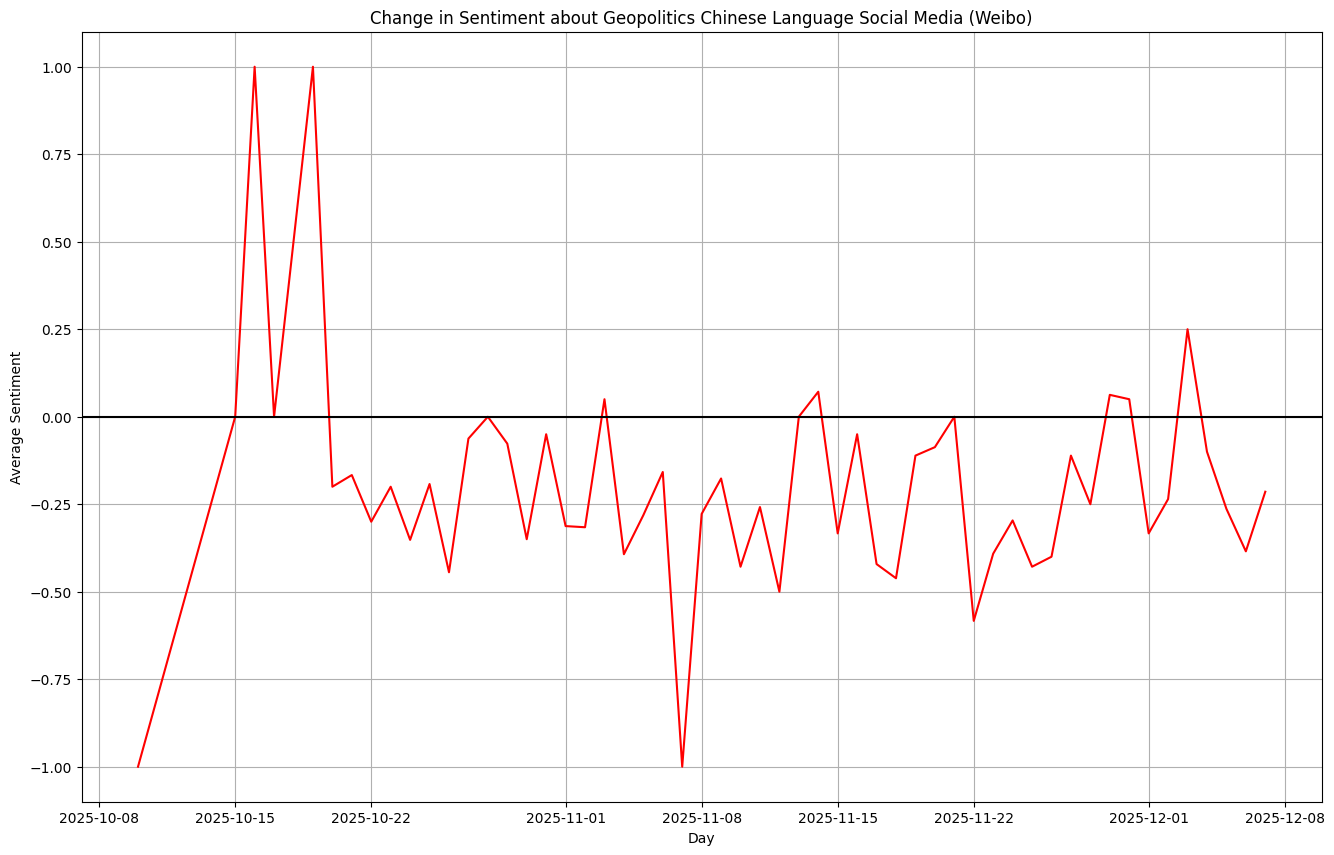

In [364]:
#Other way to plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(16, 10))
ax.plot(topic_plots_1_df["Date"], topic_plots_1_df["avg_sent"], color = "red")
plt.axhline(0, color = "black")
plt.title("Change in Sentiment about Geopolitics Chinese Language Social Media (Weibo)")
plt.xlabel("Day") 
plt.ylabel("Average Sentiment")
plt.grid()

In [10]:
#Alright lets try the transformer like chatgpt says 
#%pip install transformers

In [9]:
#from transformers import AutoTokenizer, AutoModel

#tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
#model = AutoModel.from_pretrained("bert-base-chinese")

In [12]:
#%pip install torch --index-url https://download.pytorch.org/whl/cpu

In [11]:
#text = "你好世界"
#inputs = tokenizer(text, return_tensors="pt")
#outputs = model(**inputs)

#print(outputs.last_hidden_state.shape)

In [13]:
#Step 1: Import data
#column_names = ['Sentiment', 'Text']
#chinese_data = pd.read_csv("/Users/johncburns/Documents/New_Research/Blue Sky/Weibo/China_Data/test.csv", names = column_names, header = None)
#chinese_data.head()

In [6]:
#%pip install datasets
import transformers

/opt/anaconda3/envs/old_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
#Fix the sentiment
#chinese_data["Edit_Sentiment"] = 0
#lencd = len(chinese_data)
#for i in range(0, lencd):
#    chinese_data["Edit_Sentiment"][i] = chinese_data["Sentiment"][i] - 1
#chinese_data.tail()

In [8]:
#Drop Sentiment column
#cd_5 = chinese_data.drop('Sentiment', axis=1)
#cd_5.tail()

In [3]:
#X_train_full, X_test
#%pip install accelerate
#import accelerate
#https://huggingface.co/google-bert/bert-base-chinese
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch
from sklearn.model_selection import train_test_split

/opt/anaconda3/envs/old_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import torch
from sklearn.model_selection import train_test_split

# Example dataset
# Replace these with your actual CSV / dataset
#cd_5.tail()
texts = cd_5["Text"]
labels = cd_5["Edit_Sentiment"]
#texts = ["我很开心", "我很难过", "今天真糟糕", "我非常满意"]
#labels = [1, 0, 0, 1]  # 1 = positive, 0 = negative

dataset = Dataset.from_dict({"text": texts, "label": labels})

dataset = dataset.train_test_split(test_size=0.2)

#Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")

# Tokenize the dataset
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True, max_length=128)

dataset = dataset.map(tokenize, batched=True)

# Set dataset format for PyTorch
dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# Load model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-chinese",
    num_labels=2  # Binary sentiment
)

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=8,   # adjust for your GPU/CPU memory
    per_device_eval_batch_size=8,
    #evaluation_strategy="epoch",
    #save_strategy="epoch",
    logging_dir="./logs",
    learning_rate=2e-5,
    logging_steps=10,
    save_total_limit=2,
    #load_best_model_at_end=True
)

#Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],  # in real use, split train/test
)

#Train!
trainer.train()

Loading weights: 100%|████████████████| 199/199 [00:00<00:00, 2880.30it/s, Materializing param=bert.pooler.dense.weight]
BertForSequenceClassification LOAD REPORT from: bert-base-chinese
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initiali

Step,Training Loss
10,0.707417
20,0.691648
30,0.644494
40,0.736907
50,0.673365
60,0.636046
70,0.680729
80,0.670203
90,0.609583
100,0.699035


Writing model shards: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.68it/s]


TrainOutput(global_step=50000, training_loss=0.5153628708553314, metrics={'train_runtime': 12360.953, 'train_samples_per_second': 32.36, 'train_steps_per_second': 4.045, 'total_flos': 2.6311105536e+16, 'train_loss': 0.5153628708553314, 'epoch': 1.0})

In [12]:
#Evaluation
sentences = ["我今天很高兴", "这太糟糕了"]
inputs = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")

device = torch.device("cpu")
model.to(device)
#dataset = dataset.to(device)

with torch.no_grad():
    outputs = model(**inputs)
    predictions = torch.argmax(outputs.logits, dim=-1)

for s, p in zip(sentences, predictions):
    label = "positive" if p.item() == 1 else "negative"
    print(f"Text: {s} -> Sentiment: {label}")

Text: 我今天很高兴 -> Sentiment: positive
Text: 这太糟糕了 -> Sentiment: negative


In [14]:
#test1 = weibo_data["Text"][700]
#Save model:
#model.save_pretrained("/Users/johncburns/Documents/New_Research/Blue Sky/Chinese_BERT/sentiment_model")
#tokenizer.save_pretrained("/Users/johncburns/Documents/New_Research/Blue Sky/Chinese_BERT/sentiment_model")

Writing model shards: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  7.13it/s]


('/Users/johncburns/Documents/New_Research/Blue Sky/Chinese_BERT/sentiment_model/tokenizer_config.json',
 '/Users/johncburns/Documents/New_Research/Blue Sky/Chinese_BERT/sentiment_model/tokenizer.json')

In [5]:
#test to see if the model works
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("/Users/johncburns/Documents/New_Research/Blue Sky/Chinese_BERT/sentiment_model")
tokenizer = AutoTokenizer.from_pretrained("/Users/johncburns/Documents/New_Research/Blue Sky/Chinese_BERT/sentiment_model")

print("Model and tokenizer loaded successfully!")

Loading weights: 100%|███████████████████████| 201/201 [00:00<00:00, 2397.28it/s, Materializing param=classifier.weight]

Model and tokenizer loaded successfully!


In [20]:
#results = sentiment_pipeline(test1)
#print(results)
#Import Chinese Weibo Data
import pandas as pd
weibo_data = pd.read_excel('/Users/johncburns/Documents/New_Research/Blue Sky/Weibo/ftm2_sorted_time.xlsx', engine = "openpyxl")
weibo_data.head()

,Unnamed: 0,Date,Text,Site,Link_to_post,Post_Comment
0,0,2025-10-10,我们为什么不能支持哈马斯. 虽然，犹太人的以色列非常残暴，但是 无疑，哈马斯也是一个恐怖组织...,Weibo,https://weibo.com/1376420267/Q8BYjocuP#comment,Post
1,1,2025-10-15,每位领导身边都带一位小朋友，军火放在医院和学校，平民想逃离哈马斯不允许……这就是加沙的真相,Weibo,https://weibo.com/7752315755/Q9i6tqBJ7#comment,Post
2,2,2025-10-15,毛子的正面主力始终在波兰、白俄罗斯方向，防止北约的突袭。南部的乌克兰始终是次要方向，别看打的...,Weibo,https://weibo.com/5205312904/Q9fPZqM37#comment,Post
3,3,2025-10-16,根据美国军事刊物《世界现代军用航空名录》发布的最新排名，印度的空军实力已超过中国，成为全球第...,Weibo,https://weibo.com/6244553417/Q9wc6gYcm#comment,Post
4,4,2025-10-17,想加入五常就得打服五常 联合国五常,Weibo,https://weibo.com/6130715305/Q9xjI7N0l#comment,Post


In [21]:
#results[0]['score']
list_text = list(weibo_data["Text"])
type(list_text)

list

In [22]:
#lenwd = len(weibo_data)

In [23]:
#labels = []
#scores = []
#for i in range(0, lenwd):
#    test = weibo_data["Text"][i][:200]
#    results = sentiment_pipeline(test)
#    label = results[0]["label"]
#    score = results[0]["score"]
#    labels.append(label)
#    scores.append(score) 
sentences = list_text
inputs = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")

device = torch.device("cpu")
model.to(device)
#dataset = dataset.to(device)

with torch.no_grad():
    outputs = model(**inputs)
    predictions = torch.argmax(outputs.logits, dim=-1)

label_list = []
for s, p in zip(sentences, predictions):
    label = "positive" if p.item() == 1 else "negative"
    label_list.append(label)
    #print(f"Text: {s} -> Sentiment: {label}")

In [24]:
#print(labels[0], scores[0])
weibo_data["Sentiment"] = label_list
weibo_data.head()

,Unnamed: 0,Date,Text,Site,Link_to_post,Post_Comment,Sentiment
0,0,2025-10-10,我们为什么不能支持哈马斯. 虽然，犹太人的以色列非常残暴，但是 无疑，哈马斯也是一个恐怖组织...,Weibo,https://weibo.com/1376420267/Q8BYjocuP#comment,Post,negative
1,1,2025-10-15,每位领导身边都带一位小朋友，军火放在医院和学校，平民想逃离哈马斯不允许……这就是加沙的真相,Weibo,https://weibo.com/7752315755/Q9i6tqBJ7#comment,Post,positive
2,2,2025-10-15,毛子的正面主力始终在波兰、白俄罗斯方向，防止北约的突袭。南部的乌克兰始终是次要方向，别看打的...,Weibo,https://weibo.com/5205312904/Q9fPZqM37#comment,Post,positive
3,3,2025-10-16,根据美国军事刊物《世界现代军用航空名录》发布的最新排名，印度的空军实力已超过中国，成为全球第...,Weibo,https://weibo.com/6244553417/Q9wc6gYcm#comment,Post,positive
4,4,2025-10-17,想加入五常就得打服五常 联合国五常,Weibo,https://weibo.com/6130715305/Q9xjI7N0l#comment,Post,positive


In [25]:
#negative
#weibo_data["Text"][917]
#positive
#weibo_data["Text"][2]
lenwd = len(weibo_data)
sent_num = []
for i in range(0, lenwd):
    if (weibo_data["Sentiment"][i] == "negative"):
        sent_num.append(0)
    else:
        sent_num.append(1)
weibo_data["Sent_num"] = sent_num
weibo_data.head()

,Unnamed: 0,Date,Text,Site,Link_to_post,Post_Comment,Sentiment,Sent_num
0,0,2025-10-10,我们为什么不能支持哈马斯. 虽然，犹太人的以色列非常残暴，但是 无疑，哈马斯也是一个恐怖组织...,Weibo,https://weibo.com/1376420267/Q8BYjocuP#comment,Post,negative,0
1,1,2025-10-15,每位领导身边都带一位小朋友，军火放在医院和学校，平民想逃离哈马斯不允许……这就是加沙的真相,Weibo,https://weibo.com/7752315755/Q9i6tqBJ7#comment,Post,positive,1
2,2,2025-10-15,毛子的正面主力始终在波兰、白俄罗斯方向，防止北约的突袭。南部的乌克兰始终是次要方向，别看打的...,Weibo,https://weibo.com/5205312904/Q9fPZqM37#comment,Post,positive,1
3,3,2025-10-16,根据美国军事刊物《世界现代军用航空名录》发布的最新排名，印度的空军实力已超过中国，成为全球第...,Weibo,https://weibo.com/6244553417/Q9wc6gYcm#comment,Post,positive,1
4,4,2025-10-17,想加入五常就得打服五常 联合国五常,Weibo,https://weibo.com/6130715305/Q9xjI7N0l#comment,Post,positive,1


In [26]:
# Create a dictionary
#data_dict = {'Labels_sent': labels, 'Score_sent': scores}

# Create the DataFrame
#df_from_dict = pd.DataFrame(data_dict)
#print(df_from_dict)
#Sent of Posts by Date
WD_Date_sent = weibo_data.groupby("Date")["Sent_num"].sum()

In [27]:
#Sent of Posts by Date
WD_Date_count = weibo_data.groupby("Date")["Date"].count()

In [28]:
#Create data set to get the average sentiment per day
avg_sent_df = pd.concat([WD_Date_sent, WD_Date_count], axis = 1)
avg_sent_df.head()

,Sent_num,Date
Date,,
2025-10-10,0,1
2025-10-15,2,2
2025-10-16,1,1
2025-10-17,1,1
2025-10-19,1,1


In [29]:
avg_sent_df["avg_sent"] = avg_sent_df["Sent_num"] / avg_sent_df["Date"]
avg_sent_df.tail()

,Sent_num,Date,avg_sent
Date,,,
2025-12-03,2,12,0.166667
2025-12-04,6,10,0.600000
2025-12-05,5,19,0.263158
2025-12-06,6,13,0.461538
2025-12-07,3,14,0.214286


In [30]:
topic_plots_1 = avg_sent_df["avg_sent"]
topic_plots_1_df = topic_plots_1.to_frame().reset_index()
topic_plots_1_df.tail()

,Date,avg_sent
49,2025-12-03,0.166667
50,2025-12-04,0.600000
51,2025-12-05,0.263158
52,2025-12-06,0.461538
53,2025-12-07,0.214286


In [35]:
#Output data
weibo_data.to_excel('/Users/johncburns/Documents/New_Research/Blue Sky/Analysis_1_16/Data_w_Sent/WeiboOct10.xlsx', index=False, sheet_name='MySheet') 

In [31]:
#topic_plots_1_df["avg_sent"].mean()
sumnum1 = int(avg_sent_df["Sent_num"].sum())
avgsent1 = sumnum1 / len(weibo_data)
avgsent1

0.2993492407809111

In [32]:
#topic_plots_1_df["avg_sent"].std()

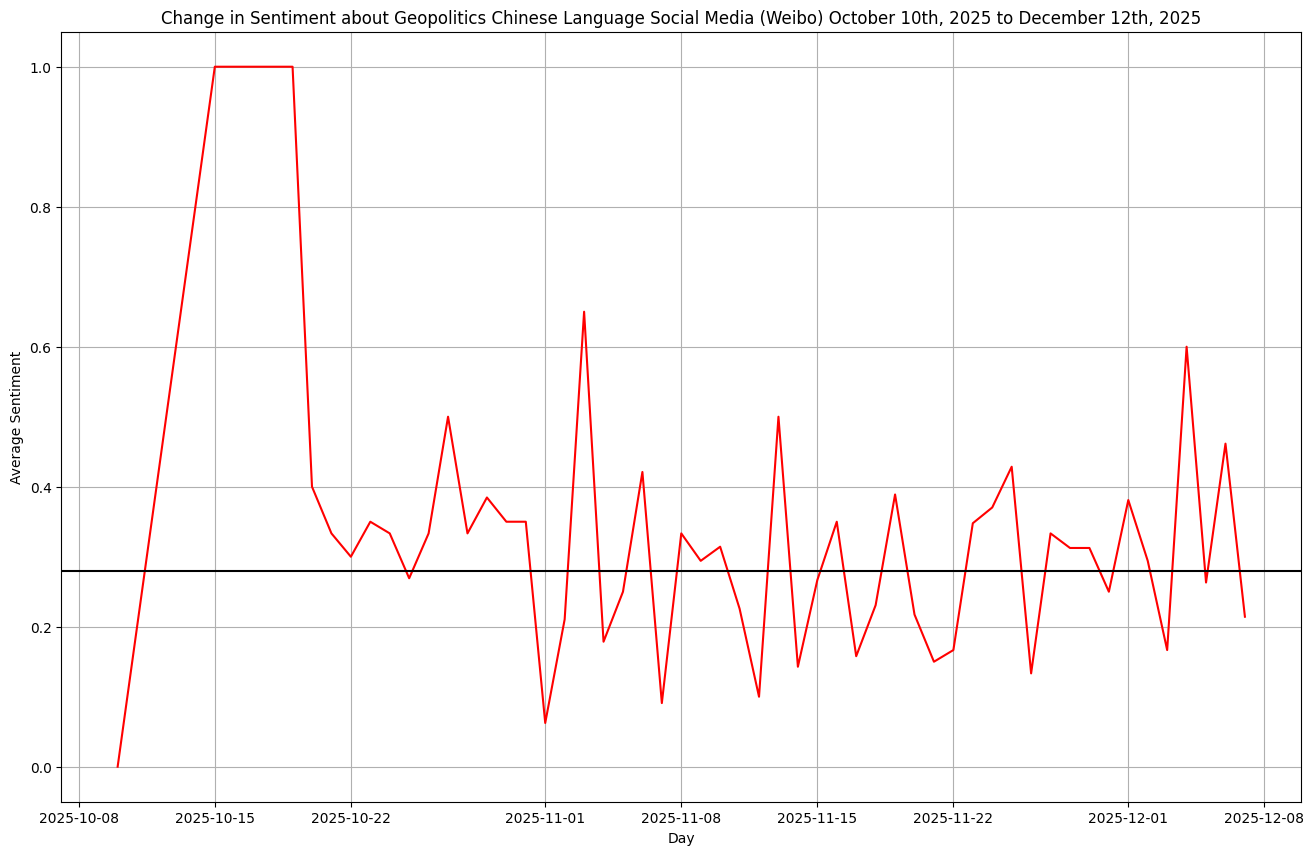

In [34]:
#Other way to plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(16, 10))
ax.plot(topic_plots_1_df["Date"], topic_plots_1_df["avg_sent"], color = "red")
plt.axhline(0.28, color = "black")
plt.title("Change in Sentiment about Geopolitics Chinese Language Social Media (Weibo) October 10th, 2025 to December 12th, 2025")
plt.xlabel("Day") 
plt.ylabel("Average Sentiment")
plt.grid()
plt.savefig("/Users/johncburns/Documents/New_Research/Blue Sky/Sentiment_Charts/Oct10_Dec12_Chinese.png") 

In [36]:
###################################################################################
#Second Segment 1/16 - 2/15
weibo_2026 = pd.read_excel("/Users/johncburns/Documents/New_Research/Blue Sky/Weibo_1_16/Weibo_1_16.xlsx", engine = "openpyxl")
weibo_2026.tail()

,Date,Text,Site,Link_to_post,Post_Comment
849,2026-02-14,乌克兰F-16战斗机对俄罗斯无人机的一次拦截，这种拦截有效是有效，就是贵了点。无人机的出现，...,Weibo,https://weibo.com/7387801989/QrPiKdbOc?pagetyp...,Post
850,2026-02-15,我们不会再有第二次“点到为止”了！近些年，越南实际控制了中国29个岛礁，其中21个已经完成建...,Weibo,https://weibo.com/7847098274/QrWS833Yc?pagetyp...,Post
851,2026-02-14,俄乌战争. 之初，鹅螺丝空军很凶，看着数量不少，天天轰炸。后来渐渐销声匿迹 ，一年以后只是偶...,Weibo,https://weibo.com/1202586970/QrTClbCx7?pagetyp...,Post
852,2026-02-14,俄罗斯的战略轰炸能力已落后于中国。俄空军只有22架能飞的图-95MS轰炸机和10架值班状态的...,Weibo,https://weibo.com/1403915120/QrOiB3C44?pagetyp...,Post
853,2026-02-14,黑猫突击队不如中国姑娘。印网友再次破防。中国女子特警队在阿联酋全球特警挑战赛中力压印度黑猫突...,Weibo,https://weibo.com/5984385728/QrTjktwCR?pagetyp...,Post


In [37]:
#Get text list
list_text_2 = list(weibo_2026["Text"])
type(list_text_2)

list

In [38]:
#Sentence 2
sentences2 = list_text_2
inputs = tokenizer(sentences2, padding=True, truncation=True, return_tensors="pt")

device = torch.device("cpu")
model.to(device)
#dataset = dataset.to(device)

with torch.no_grad():
    outputs = model(**inputs)
    predictions = torch.argmax(outputs.logits, dim=-1)

label_list_2 = []
for s, p in zip(sentences, predictions):
    label = "positive" if p.item() == 1 else "negative"
    label_list_2.append(label)

In [39]:
#print(labels[0], scores[0])
weibo_2026["Sentiment"] = label_list_2
weibo_2026.head()

,Date,Text,Site,Link_to_post,Post_Comment,Sentiment
0,2026-01-15,伊朗的两手准备. 本来已经差点打起来了，美国对伊朗打击在最后一刻被叫停. 据以色列媒体Wal...,Weibo,https://weibo.com/6036510456/QnmtD0yCV?pagetyp...,Post,negative
1,2026-01-15,很多人不明白，俄乌打了快四年了，占了乌克兰20%的土地，俄罗斯为什么还不收手？答案很简单，随...,Weibo,https://weibo.com/7677670342/QnfjcnsEa?pagetyp...,Post,negative
2,2026-01-03,两场“斩首”行动的天壤之别：为什么俄军抓泽连斯基失败，而美军抓马杜罗成功？因为马杜罗治理下委...,Weibo,https://weibo.com/6065607249/Qlx0L0thf?pagetyp...,Post,negative
3,2026-01-05,军事行动.美国三角洲部队在委内瑞拉执行抓捕行动的画面流出（由当地人拍摄），这绝对是最棒的,Weibo,https://weibo.com/1740979351/QlK4sgJLT?pagetyp...,Post,positive
4,2026-01-14,美国NBC新闻：知情人士称，特朗普希望针对伊朗的军事行动迅速果断，要“确保一击致命”。但两位...,Weibo,https://weibo.com/5564927603/QncqayTKz?pagetyp...,Post,negative


In [40]:
#negative
#weibo_data["Text"][917]
#positive
#weibo_data["Text"][2]
lenwd = len(weibo_2026)
sent_num_2 = []
for i in range(0, lenwd):
    if (weibo_2026["Sentiment"][i] == "negative"):
        sent_num_2.append(0)
    else:
        sent_num_2.append(1)
weibo_2026["Sent_num"] = sent_num_2
weibo_2026.head()

,Date,Text,Site,Link_to_post,Post_Comment,Sentiment,Sent_num
0,2026-01-15,伊朗的两手准备. 本来已经差点打起来了，美国对伊朗打击在最后一刻被叫停. 据以色列媒体Wal...,Weibo,https://weibo.com/6036510456/QnmtD0yCV?pagetyp...,Post,negative,0
1,2026-01-15,很多人不明白，俄乌打了快四年了，占了乌克兰20%的土地，俄罗斯为什么还不收手？答案很简单，随...,Weibo,https://weibo.com/7677670342/QnfjcnsEa?pagetyp...,Post,negative,0
2,2026-01-03,两场“斩首”行动的天壤之别：为什么俄军抓泽连斯基失败，而美军抓马杜罗成功？因为马杜罗治理下委...,Weibo,https://weibo.com/6065607249/Qlx0L0thf?pagetyp...,Post,negative,0
3,2026-01-05,军事行动.美国三角洲部队在委内瑞拉执行抓捕行动的画面流出（由当地人拍摄），这绝对是最棒的,Weibo,https://weibo.com/1740979351/QlK4sgJLT?pagetyp...,Post,positive,1
4,2026-01-14,美国NBC新闻：知情人士称，特朗普希望针对伊朗的军事行动迅速果断，要“确保一击致命”。但两位...,Weibo,https://weibo.com/5564927603/QncqayTKz?pagetyp...,Post,negative,0


In [41]:
#Sent of Posts by Date
WD_Date_sent_26 = weibo_2026.groupby("Date")["Sent_num"].sum()
WD_Date_sent_26.head()

Date
2026-01-03    0
2026-01-05    2
2026-01-06    1
2026-01-07    0
2026-01-08    0
Name: Sent_num, dtype: int64

In [42]:
#Sent of Posts by Date
WD_Date_count_26 = weibo_2026.groupby("Date")["Date"].count()
WD_Date_count_26.head()

Date
2026-01-03    3
2026-01-05    2
2026-01-06    3
2026-01-07    2
2026-01-08    2
Name: Date, dtype: int64

In [43]:
#Create data set to get the average sentiment per day
avg_sent_26 = pd.concat([WD_Date_sent_26, WD_Date_count_26], axis = 1)
avg_sent_26_2 = avg_sent_26.rename(columns={"Date": "count"})
as26_sort = avg_sent_26_2.sort_values(by='Date', ascending=True)
as26_sort.head()
#avg_sent_26_2.head()

,Sent_num,count
Date,,
2026-01-03,0,3
2026-01-05,2,2
2026-01-06,1,3
2026-01-07,0,2
2026-01-08,0,2


In [44]:
as26_sort["avg_sent"] = as26_sort["Sent_num"] / as26_sort["count"]
as26_sort.tail()

,Sent_num,count,avg_sent
Date,,,
2026-02-11,7,30,0.233333
2026-02-12,1,18,0.055556
2026-02-13,5,27,0.185185
2026-02-14,6,21,0.285714
2026-02-15,2,13,0.153846


In [45]:
topic_plots_26 = as26_sort["avg_sent"]
topic_plots_26_df = topic_plots_26.to_frame().reset_index()
topic_plots_26_df.tail()

,Date,avg_sent
38,2026-02-11,0.233333
39,2026-02-12,0.055556
40,2026-02-13,0.185185
41,2026-02-14,0.285714
42,2026-02-15,0.153846


In [46]:
#topic_plots_26_df["avg_sent"].mean()
sumnum = int(as26_sort["Sent_num"].sum())
avgsent = sumnum / len(weibo_2026)
avgsent

0.23185011709601874

In [47]:
#topic_plots_26_df["avg_sent"].std()

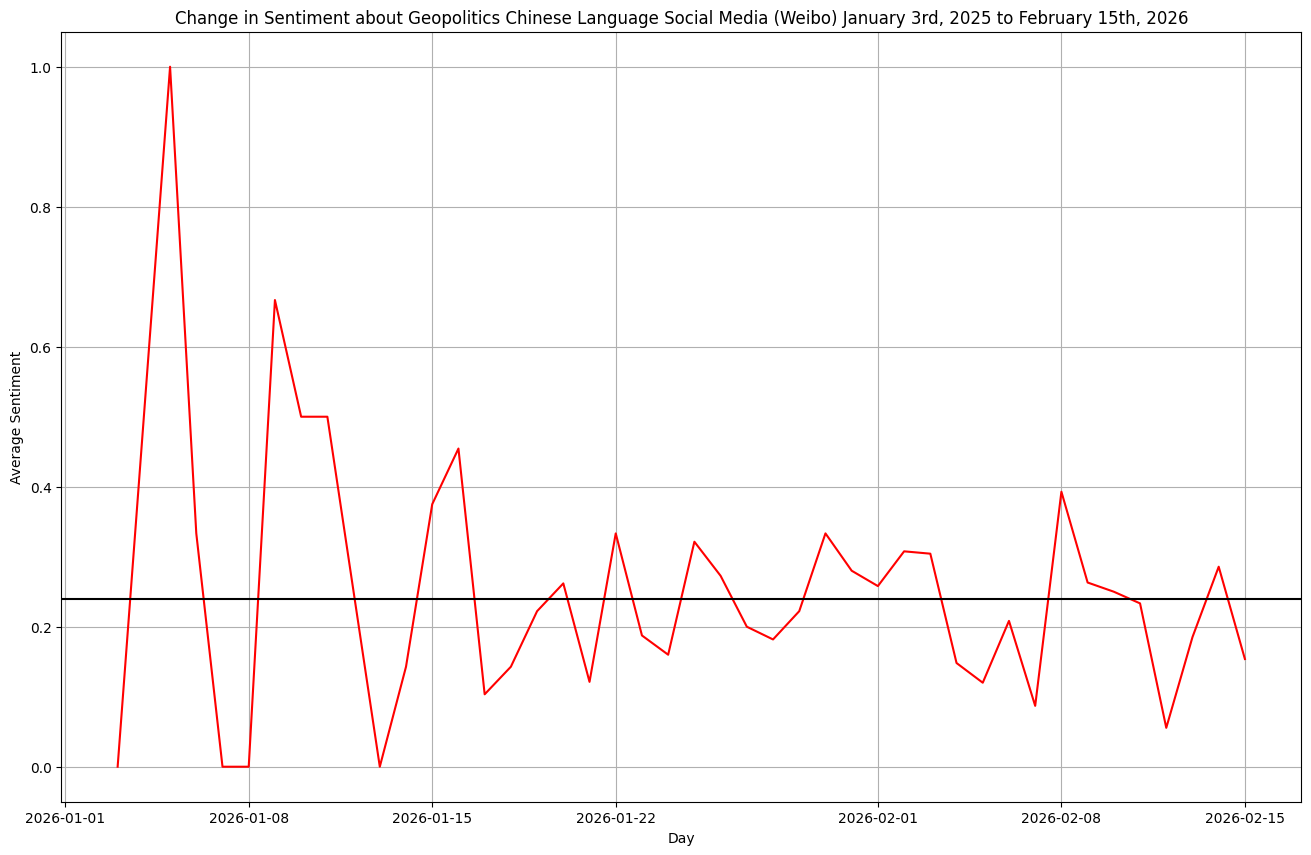

In [48]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.plot(topic_plots_26_df["Date"], topic_plots_26_df["avg_sent"], color = "red")
plt.axhline(0.24, color = "black")
plt.title("Change in Sentiment about Geopolitics Chinese Language Social Media (Weibo) January 3rd, 2025 to February 15th, 2026")
plt.xlabel("Day") 
plt.ylabel("Average Sentiment")
plt.grid()
plt.savefig("/Users/johncburns/Documents/New_Research/Blue Sky/Sentiment_Charts/Jan3_Feb15th_Chinese.png") 

In [49]:
sumnum = int(as26_sort["Sent_num"].sum())
avgsent = sumnum / len(weibo_2026)
avgsent

0.23185011709601874

In [3]:
#Evaluating Chinese Sentiment Model 
from transformers import Trainer
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=32,
    do_train=False,
    do_eval=True,
)

In [4]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    }

In [10]:
from datasets import Dataset
import pandas as pd
val_df = pd.read_csv("/Users/johncburns/Documents/New_Research/Blue Sky/Weibo/China_Data/X_test.csv")  
val_df.head()

,Unnamed: 0,Text,Edit_Sentiment
0,478349,跟向阳坊的东西差不多嘛，也是主打乳酪蛋糕；\n布里欧，名字有点怪，上面是布丁，下面是面包，还...,0
1,306307,吃过几次，几种锅味道都尚可，没有什么特别表现，中规中矩。\n香辣蟹不错，蛮有味道的，配料也挺...,0
2,110678,这家还真是不错。。。式样多彩，，，那天去拍照看得 我眼花缭乱。。真是太美。。。\n小妮子的服...,1
3,474896,排队等待。。。很多是内地的游客，这次来的重点就是想买包包的，买到了喜欢的款，牛皮的会比较耐磨...,1
4,182106,今年214来这边吃的~离公司很近~\n餐厅环境的确比较诡异~哈~\n晚上拍出来的照片 像鬼屋...,1


In [14]:
# REQUIRED: rename label column to "labels"
val_df = val_df.rename(columns={"Edit_Sentiment": "labels", "Text": "text"})
val_df.head()

,Unnamed: 0,text,labels
0,478349,跟向阳坊的东西差不多嘛，也是主打乳酪蛋糕；\n布里欧，名字有点怪，上面是布丁，下面是面包，还...,0
1,306307,吃过几次，几种锅味道都尚可，没有什么特别表现，中规中矩。\n香辣蟹不错，蛮有味道的，配料也挺...,0
2,110678,这家还真是不错。。。式样多彩，，，那天去拍照看得 我眼花缭乱。。真是太美。。。\n小妮子的服...,1
3,474896,排队等待。。。很多是内地的游客，这次来的重点就是想买包包的，买到了喜欢的款，牛皮的会比较耐磨...,1
4,182106,今年214来这边吃的~离公司很近~\n餐厅环境的确比较诡异~哈~\n晚上拍出来的照片 像鬼屋...,1


In [15]:
val_dataset = Dataset.from_pandas(val_df)

In [16]:
#Tokenize
def tokenize_function(examples):
    return tokenizer(
        examples["text"],  # change if your text column has different name
        truncation=True,
        padding="max_length",
        max_length=128,
    )

val_dataset = val_dataset.map(tokenize_function, batched=True)

Map: 100%|████████████████████████████████████████████████████████████| 125000/125000 [00:05<00:00, 22279.06 examples/s]


In [17]:
#Set format for Trainer
val_dataset = val_dataset.remove_columns(["text", "Unnamed: 0"])  # keep labels
val_dataset.set_format("torch")

In [18]:
print(val_dataset.column_names)

['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [19]:
#Evaluation time
trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

metrics = trainer.evaluate()
print(metrics)

/opt/anaconda3/envs/old_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.464557021856308, 'eval_model_preparation_time': 0.0006, 'eval_accuracy': 0.779384, 'eval_f1': 0.7835723086823786, 'eval_precision': 0.7679799393874129, 'eval_recall': 0.7998109459113047, 'eval_runtime': 963.7687, 'eval_samples_per_second': 129.699, 'eval_steps_per_second': 4.054}


In [50]:
#Output Second Data Set
#Output data
weibo_2026.to_excel('/Users/johncburns/Documents/New_Research/Blue Sky/Analysis_1_16/Data_w_Sent/WeiboJan3.xlsx', index=False, sheet_name='MySheet') 

In [1]:
#Better Accuracy Measures:
#test to see if the model works
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("/Users/johncburns/Documents/New_Research/Blue Sky/Chinese_BERT/sentiment_model")
tokenizer = AutoTokenizer.from_pretrained("/Users/johncburns/Documents/New_Research/Blue Sky/Chinese_BERT/sentiment_model")

print("Model and tokenizer loaded successfully!")

/opt/anaconda3/envs/old_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|███████████████████████| 201/201 [00:00<00:00, 2316.02it/s, Materializing param=classifier.weight]

Model and tokenizer loaded successfully!


In [8]:
from datasets import Dataset
import pandas as pd
new_column_names = ['Sentiment', 'Age', 'Text']
val_df = pd.read_csv("/Users/johncburns/Documents/New_Research/Blue Sky/Chinese_BERT/Binary_test/binary_test.csv",  header=0, names=new_column_names)  
val_df.tail()

,Sentiment,Age,Text
359994,1,NaN,龟速的物流，四五天才到，客服太度过差
359995,1,NaN,龟速的物流，龟速的效率！等了好几天终于等到了，打开来卖家还发错货了，明明买的是79元的长款，...
359996,1,NaN,龟速般的发货，这个订单让我等了二十天！
359997,1,NaN,龟速、超级慢！同样都是15号下单、别家第二天就到了、这家19号才到、
359998,1,NaN,龟速送货，太慢醉了。


In [9]:
val_df["Sentiment_Fixed"] = val_df["Sentiment"] - 1
val_df.tail()

,Sentiment,Age,Text,Sentiment_Fixed
359994,1,NaN,龟速的物流，四五天才到，客服太度过差,0
359995,1,NaN,龟速的物流，龟速的效率！等了好几天终于等到了，打开来卖家还发错货了，明明买的是79元的长款，...,0
359996,1,NaN,龟速般的发货，这个订单让我等了二十天！,0
359997,1,NaN,龟速、超级慢！同样都是15号下单、别家第二天就到了、这家19号才到、,0
359998,1,NaN,龟速送货，太慢醉了。,0


In [10]:
val_df2 = val_df.sample(10000).reset_index(drop = True)
val_df2.tail()

,Sentiment,Age,Text,Sentiment_Fixed
9995,2,NaN,不错，就是感觉比一淘贵,1
9996,1,NaN,包包还发错了。,0
9997,2,NaN,不错的东东 正品 以后就认准京东了,1
9998,2,NaN,满意衣服很好GOOD!!!,1
9999,1,NaN,我就不想说什么了 其实帮别人买的 买时候差了好久选择了紫吕蓝色条敏感性 结果回来以后是粉色条...,0


In [12]:
val_df2 = val_df2.rename(columns={"Sentiment_Fixed": "labels", "Text": "text"})
val_df2.tail()

,Sentiment,Age,text,labels
9995,2,NaN,不错，就是感觉比一淘贵,1
9996,1,NaN,包包还发错了。,0
9997,2,NaN,不错的东东 正品 以后就认准京东了,1
9998,2,NaN,满意衣服很好GOOD!!!,1
9999,1,NaN,我就不想说什么了 其实帮别人买的 买时候差了好久选择了紫吕蓝色条敏感性 结果回来以后是粉色条...,0


In [14]:
val_df3 = val_df2.drop(columns = ["Sentiment", "Age"]) 
val_df3.tail()

,text,labels
9995,不错，就是感觉比一淘贵,1
9996,包包还发错了。,0
9997,不错的东东 正品 以后就认准京东了,1
9998,满意衣服很好GOOD!!!,1
9999,我就不想说什么了 其实帮别人买的 买时候差了好久选择了紫吕蓝色条敏感性 结果回来以后是粉色条...,0


In [15]:
val_dataset = Dataset.from_pandas(val_df3)

In [16]:
#Tokenize
def tokenize_function(examples):
    return tokenizer(
        examples["text"],  # change if your text column has different name
        truncation=True,
        padding="max_length",
        max_length=128,
    )

val_dataset = val_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 43129.67 examples/s]


In [19]:
#Set format for Trainer
#Set format for Trainer
val_dataset = val_dataset.remove_columns(["text"])  # keep labels
val_dataset.set_format("torch")

In [20]:
print(val_dataset.column_names)

['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [21]:
#Evaluation time
trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

metrics = trainer.evaluate()
print(metrics)

/opt/anaconda3/envs/old_env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.35617783665657043, 'eval_model_preparation_time': 0.0007, 'eval_accuracy': 0.8485, 'eval_f1': 0.8297944051230199, 'eval_precision': 0.9349367088607595, 'eval_recall': 0.7459099171884468, 'eval_runtime': 77.263, 'eval_samples_per_second': 129.428, 'eval_steps_per_second': 4.051}


In [1]:
################
import pandas as pd 
df = pd.read_csv('/Users/johncburns/Documents/vocab_bert_chinese.txt', sep='\t')
df.head()

,[PAD]
0,[unused1]
1,[unused2]
2,[unused3]
3,[unused4]
4,[unused5]


In [2]:
df.tail()

,[PAD]
7911,##￥
7912,##👍
7913,##🔥
7914,##😂
7915,##😎


In [3]:
len(df)

7916